# Mini kutatás: WTI nyersolaj határidős árak

Ez a notebook a mappában található **Crude Oil WTI Futures Historical Data.csv** fájlt dolgozza fel. A cél hat érthető vizualizáció készítése, majd mindegyik alatt rövid, magyar nyelvű elemzés és következtetés.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
})

DATA_PATH = Path("Crude Oil WTI Futures Historical Data.csv")


def parse_volume(value: str) -> float:
    text = str(value).replace(",", "").strip()
    if text.endswith("K"):
        return float(text[:-1]) * 1_000
    if text.endswith("M"):
        return float(text[:-1]) * 1_000_000
    return float(text)


df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df = df.sort_values("Date").reset_index(drop=True)

for col in ["Price", "Open", "High", "Low"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Volume"] = df["Vol."].apply(parse_volume)
df["Change_pct"] = (
    df["Change %"].astype(str).str.replace("%", "", regex=False).astype(float)
)
df["Daily_range"] = df["High"] - df["Low"]
df["Month"] = df["Date"].dt.to_period("M").astype(str)

print(f"Megfigyelések száma: {len(df)}")
print(f"Időszak: {df['Date'].min().date()} – {df['Date'].max().date()}")
df.head()

Megfigyelések száma: 23
Időszak: 2026-05-18 – 2026-06-17


,Date,Price,Open,High,Low,Vol.,Change %,Volume,Change_pct,Daily_range,Month
0,2026-05-18,108.66,106.00,109.47,102.65,117.91K,3.07%,117910.0,3.07,6.82,2026-05
1,2026-05-19,107.77,107.11,109.24,106.76,30.41K,-0.82%,30410.0,-0.82,2.48,2026-05
2,2026-05-20,98.26,104.12,104.45,96.94,320.03K,-8.82%,320030.0,-8.82,7.51,2026-05
3,2026-05-21,96.35,98.95,102.66,95.76,345.48K,-1.94%,345480.0,-1.94,6.90,2026-05
4,2026-05-22,96.60,98.00,99.43,94.73,261.14K,0.26%,261140.0,0.26,4.70,2026-05


## 1. grafikon – Záróár trendje

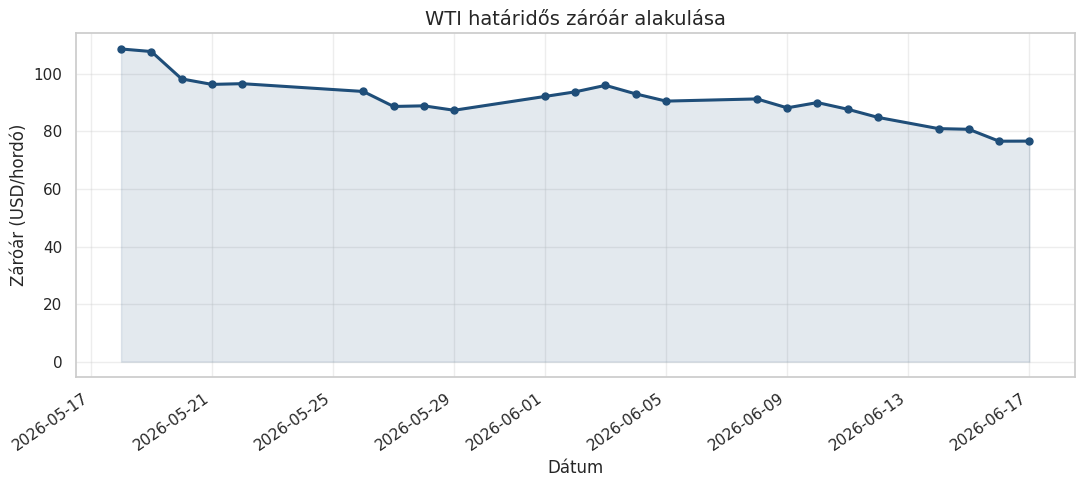

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["Date"], df["Price"], color="#1f4e79", linewidth=2.2, marker="o", markersize=5)
ax.fill_between(df["Date"], df["Price"], alpha=0.12, color="#1f4e79")
ax.set_title("WTI határidős záróár alakulása")
ax.set_xlabel("Dátum")
ax.set_ylabel("Záróár (USD/hordó)")
ax.grid(True, alpha=0.35)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Elemzés és következtetés**

Az első ábra azt mutatja, hogy a vizsgált, mintegy egy hónapos időszakban a WTI határidős záróára markáns csökkenő trendet követett. A sorozat a mintavételi ablak elején, 2026 május közepén még 108 USD/hordó körüli szinten zárt, majd fokozatosan, időnként rövid oldalazásokkal erodálódott. A csökkenés nem egyenletes volt: voltak napok, amikor az ár enyhén visszakapaszkodott, de a magasabb csúcsok és mélypontok is egyre alacsonyabbak lettek, ami klasszikus lefelé mutató piaci struktúrát jelez. A hónap második felében, különösen június közepén a zuhanás felgyorsult, és a záróár a 77 USD/hordó közelébe süllyedt. Ez a mintegy 30 százalékos relatív visszaesés arra utal, hogy a piac tartósan árazta be a gyengébb keresletet, geopolitikai bizonytalanságot vagy túlkínálatot. A trendvonal alatti kitöltés vizuálisan is erősíti a negatív irányt: a befektetők számára rövid távon a short irány volt az erősebb. Ugyanakkor a legutóbbi napok enyhe stabilizációja arra is figyelmeztet, hogy extrém esés után technikai korrekció vagy konszolidáció is bekövetkezhet. Összességében a záróár-idősor alapján a mini kutatás fő üzenete egyértelmű: a vizsgált időszakban a nyersolaj ára strukturálisan gyengült, és a piaci hangulat inkább óvatos, kockázatkerülő volt.

## 2. grafikon – Záróárak eloszlása

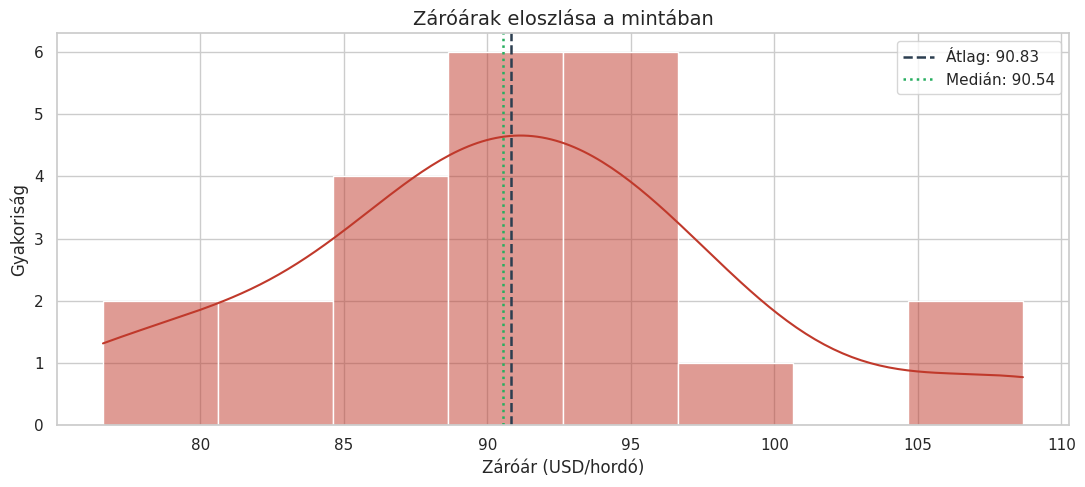

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(df["Price"], bins=8, kde=True, color="#c0392b", edgecolor="white", ax=ax)
ax.axvline(df["Price"].mean(), color="#2c3e50", linestyle="--", linewidth=1.8, label=f"Átlag: {df['Price'].mean():.2f}")
ax.axvline(df["Price"].median(), color="#27ae60", linestyle=":", linewidth=1.8, label=f"Medián: {df['Price'].median():.2f}")
ax.set_title("Záróárak eloszlása a mintában")
ax.set_xlabel("Záróár (USD/hordó)")
ax.set_ylabel("Gyakoriság")
ax.legend()
plt.tight_layout()
plt.show()

**Elemzés és következtetés**

A hisztogram megmutatja, hogy a záróárak nem egyetlen „tipikus” érték körül csoportosultak, hanem viszonylag széles sávban oszlottak el. A legtöbb megfigyelés a 85–100 USD/hordó közötti tartományban helyezkedik el, ami azt jelenti, hogy a vizsgált hónap nagy részében a piac még magasabb árszinten működött. Ugyanakkor az eloszlás jobb oldali farka rövidebb, míg az alsó tartomány felé több adatpont tolódott a periodus végén, amikor az árak gyorsan estek. Az átlag és a medián összehasonlítása fontos: ha az átlag magasabb marad a mediánnál, az arra utalhat, hogy néhány korai, magasabb ár „húzza felfelé” a központi tendenciát, miközben a frissebb adatok már alacsonyabb szinten vannak. A KDE-görbe domború formája azt sugallja, hogy nincs extrém kettős csúcs, de a balra tolódó tömeg a piaci gyengülés véglegesedését tükrözi. Statisztikai szempontból ez azt jelenti, hogy a kockázatkezelés során nem elég egyetlen várható értéket nézni: az ár jelentős valószínűséggel mozoghatott a teljes intervallumon belül. A következtetés tehát az, hogy bár a minta rövid, az eloszlás alapján a WTI ára ebben az időszakban instabilabb és széttartóbb volt, mint egy szűk, stabil sávban mozgó piacon.

## 3. grafikon – Napi kereskedési volumen

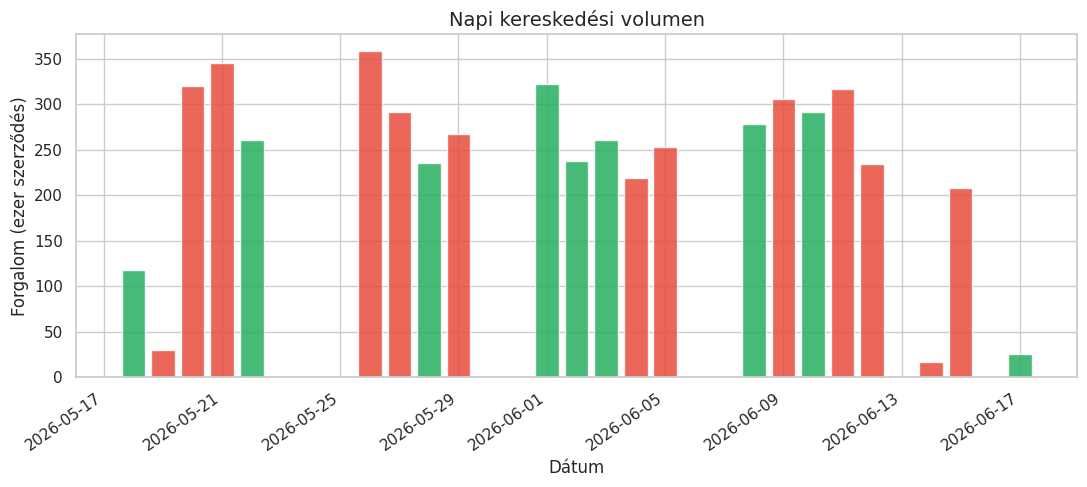

In [8]:
colors = np.where(df["Change_pct"] >= 0, "#27ae60", "#e74c3c")

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(df["Date"], df["Volume"] / 1_000, color=colors, alpha=0.85, edgecolor="white")
ax.set_title("Napi kereskedési volumen")
ax.set_xlabel("Dátum")
ax.set_ylabel("Forgalom (ezer szerződés)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Elemzés és következtetés**

A volumen oszlopdiagramja azt mutatja, hogy a kereskedési aktivitás naponta erősen ingadozott, ami tipikus a határidős piacokon, ahol hírek, makrogazdasági adatok és technikai szintek egyszerre hatnak a résztvevőkre. A vizsgált időszakban több olyan nap is volt, amikor a forgalom jelentősen meghaladta a száz- vagy akár a háromszázezer szerződéses szintet, miközben más napokon alacsonyabb, akár néhány ezer szerződés körüli aktivitás figyelhető meg. A színezés – zöld emelkedő, piros eső napokra – segít észrevenni, hogy a nagy volumenű napok nem mindig esnek egybe egyetlen irányú ármozgással, de a legnagyobb forgalmú sessionök gyakran együtt járnak erősebb napi változással. Ez arra utal, hogy amikor a piac új információt áraz be, a likviditás is megugranhat, mert több szereplő egyszerre módosítja pozícióját. A volumen csúcsai különösen fontosak a trend értelmezéséhez: tartós árcsökkenés mellett magas forgalom gyakran megerősíti a irányt, mert nem csupán technikai korrekcióról van szó. Összefoglalva a volumen-analízis azt sugallja, hogy a WTI piac ebben a mintában aktív és reaktív volt; a döntéshozók számára a csendes, alacsony volumenű napok kevésbé informatívak, míg a kiemelkedő forgalmú napok kulcsfontosságúak a trend validálásához.

## 4. grafikon – Napi százalékos árváltozás

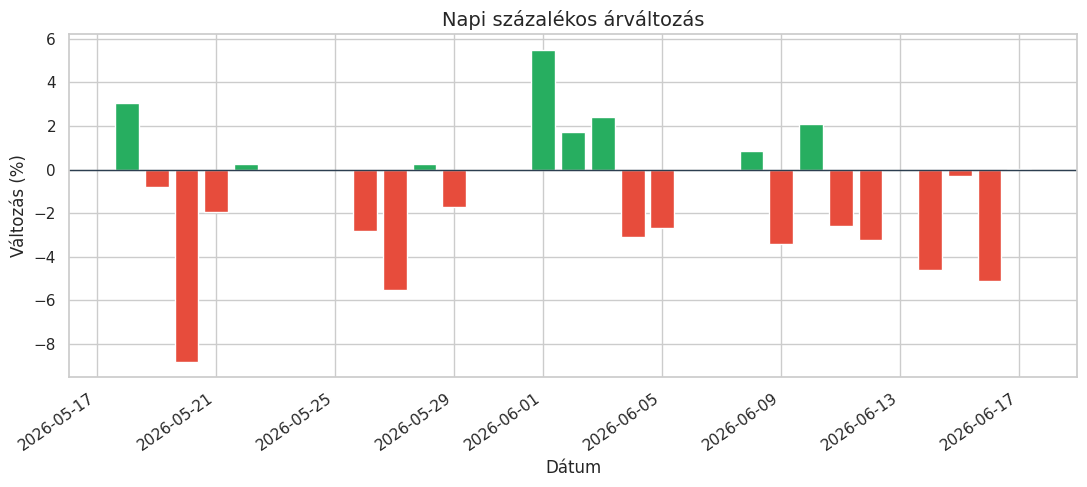

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ["#27ae60" if x >= 0 else "#e74c3c" for x in df["Change_pct"]]
ax.bar(df["Date"], df["Change_pct"], color=bar_colors, edgecolor="white")
ax.axhline(0, color="#2c3e50", linewidth=1)
ax.set_title("Napi százalékos árváltozás")
ax.set_xlabel("Dátum")
ax.set_ylabel("Változás (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Elemzés és következtetés**

A napi százalékos változások oszlopdiagramja jól szemlélteti, hogy a WTI árfolyam nem simán csúszott lefelé, hanem heves, naponta változó ingadozásokkal reagált a piaci hírekre. A nulla vonal feletti zöld oszlopok a pozitív napokat, az alatta lévő piros oszlopok a vesztes sessionöket mutatják. A mintában több olyan nap is szerepel, amikor az ár több százalékkal zuhant egyetlen kereskedési napon, ami rövid távon jelentős kockázatot jelent a tőkeáttételes pozíciók számára. Ugyanakkor vannak enyhébb, pluszban záró napok is, amelyek rövid távú technikai emelkedéseket vagy profitrealizálást tükrözhetnek egy hosszabb eső trend közepette. Fontos megfigyelés, hogy a nagy negatív napok gyakran egymást követik vagy erős piaci hangulatot erősítenek, ami önfenntartó eső spirált indíthat el, amíg új fundamentum nem állítja meg a mozgást. A diagram alapján a volatilitás aszimmetrikus: a vesztes napok abszolút értéke időnként nagyobb, mint a nyereséges napoké, ami összhangban van a korábban látott lefelé mutató trenddel. Következtetésként elmondható, hogy a piac rövid távon „hangos” volt: a befektetőknek számítaniuk kellett éles napi kilengésekre, és a kockázatkezelés – stop szintek, pozícióméretezés – kulcsszerepet játszott ebben az időszakban.

## 5. grafikon – Napi ársáv (High − Low)

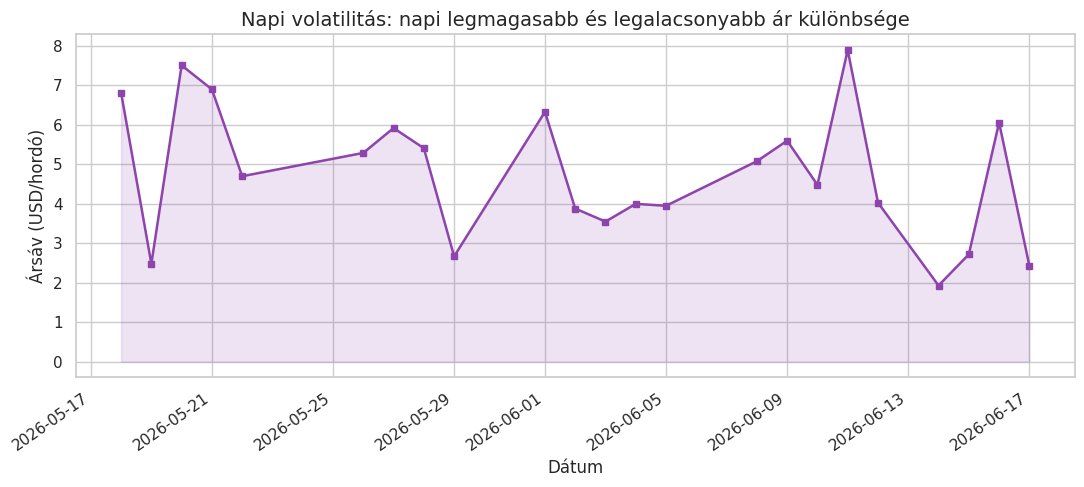

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["Date"], df["Daily_range"], color="#8e44ad", marker="s", markersize=4, linewidth=1.8)
ax.fill_between(df["Date"], df["Daily_range"], alpha=0.15, color="#8e44ad")
ax.set_title("Napi volatilitás: napi legmagasabb és legalacsonyabb ár különbsége")
ax.set_xlabel("Dátum")
ax.set_ylabel("Ársáv (USD/hordó)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Elemzés és következtetés**

Az ötödik ábra a napi ársávot, vagyis a napi maximum és minimum közötti különbséget mutatja, amely a piaci volatilitás egyik legegyszerűbb, mégis informatív mérőszáma. A WTI adatsorban ez az érték naponta jelentősen változik: vannak viszonylag nyugodt sessionök, amikor az ár szűk sávban mozog, és vannak olyan napok, amikor a kereskedők széles intervallumon belül „harcolnak” az irányért. A szélesebb ársávú napok gyakran egybeesnek nagyobb piaci bizonytalansággal, hírérzékenységgel vagy likviditási stresszel, különösen amikor az ár gyors esésbe vagy emelkedésbe kapaszkodik. A grafikon segít megkülönböztetni a csendes konszolidációt azoktól a napoktól, amikor a piac túlreagál. A vizsgált időszakban több kiemelkedő csúcs is látható, ami arra utal, hogy a nyersolaj ára nemcsak irányban, hanem ingadozás mértékében is kiszámíthatatlanabb lett. Ez különösen fontos határidős kereskedők számára, mert a szélesebb napi sáv nagyobb margin követelményt és stop-kockázatot jelenthet. Összességében a napi ársáv elemzése megerősíti: a piac nem stabil, alacsony volatilitású környezetben működött, hanem időszakonként fokozott bizonytalanságot mutatott, amely összhangban van a lefelé mutató ártrenddel és a nagy volumenű napokkal.

## 6. grafikon – Nyitó és záró ár összehasonlítása

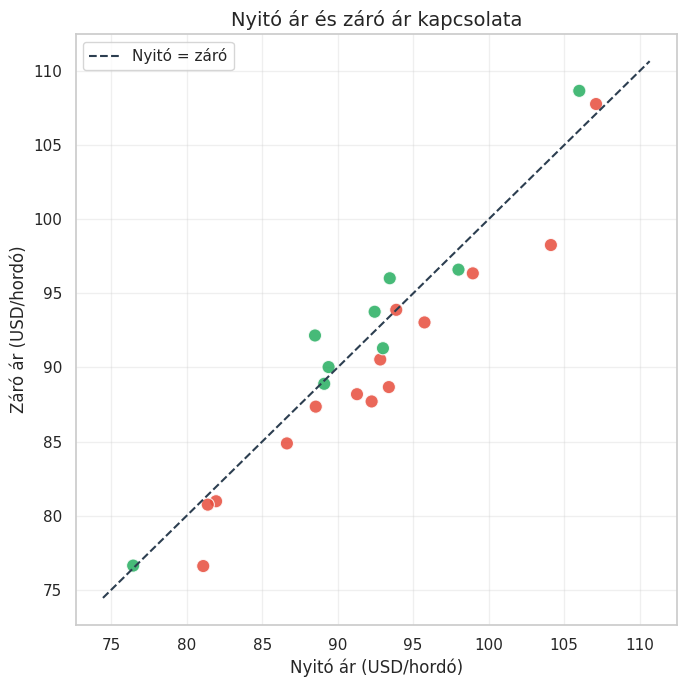

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))
palette = np.where(df["Change_pct"] >= 0, "#27ae60", "#e74c3c")
ax.scatter(df["Open"], df["Price"], c=palette, s=90, alpha=0.85, edgecolor="white", linewidth=0.8)

min_val = min(df["Open"].min(), df["Price"].min()) - 2
max_val = max(df["Open"].max(), df["Price"].max()) + 2
ax.plot([min_val, max_val], [min_val, max_val], "--", color="#2c3e50", linewidth=1.5, label="Nyitó = záró")

ax.set_title("Nyitó ár és záró ár kapcsolata")
ax.set_xlabel("Nyitó ár (USD/hordó)")
ax.set_ylabel("Záró ár (USD/hordó)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Elemzés és következtetés**

A hatodik, pontdiagram alapú ábra a nyitó és záró árak kapcsolatát vizsgálja. Az átló vonal azt jelenti, hogy az adott napon az árfolyam gyakorlatilag változatlan maradt; a pontok feletti elhelyezkedés emelkedő napot, alatti elhelyezkedés csökkenő napot sugall. A mintában több piros pont is az átló alatt helyezkedik el, ami összhangban van azzal, hogy a vizsgált időszak általános hangulata gyengébb volt, és sok sessionben a záró ár a nyitó alatt maradt. Ugyanakkor vannak zöld pontok is, amelyek azt mutatják, hogy még erős lefelé mutató trend mellett is előfordultak sikeres intraday emelkedések, jóllehet ezek gyakran nem fordították meg a nagyobb struktúrát. A pontok eloszlása azt is mutatja, hogy az árak idővel lejjebb tolódtak: a korábbi, magasabb nyitó-záró párok felső tartományban clusterelnek, míg a későbbi megfigyelések az alsó zónában sűrűsödnek. Ez vizuálisan is megerősíti a korábbi trend- és eloszlás-elemzések üzenetét. A scatter plot tehát nem csupán technikai érdekesség, hanem azt is jelzi, hogy a piac rövid távú visszapattanásai ellenére a záró értékek strukturálisan alacsonyabb szinten stabilizálódtak. A mini kutatás záró következtetése: a WTI határidős piac ebben a rövid mintában gyengélkedő, volatilis és aktívan kereskedett időszakot mutatott.

## Összegző következtetés

A hat vizualizáció együttesen azt mutatja, hogy a WTI határidős árak a vizsgált ~egy hónapban tartósan csökkentek, miközben a napi volatilitás és a kereskedési volumen jelentős ingadozást mutatott. A piac rövid távon kockázatos, hírérzékeny környezetet biztosított; hosszabb távú következtetésekhez természetesen több adat és fundamentális elemzés lenne szükséges.